In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


In [4]:
ddtr = pd.read_csv(r"C:\Users\harik\Documents\COLLEGE\SEM6\AI&EdgeComputing\detect_dataset.csv")

In [5]:
ddtr.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN


In [6]:
print(f"The Detect Dataset has {ddtr.shape[0]} rows and {ddtr.shape[1]} columns.")

The Detect Dataset has 12001 rows and 9 columns.


In [7]:
for i in ['Va', 'Vb', 'Vc']:
    ddtr[i] = ddtr[i] * 11000
ddtr.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,599.390044,-7259.130241,6659.740208,NaN,NaN
1,0,-122.235754,6.168667,116.067087,1122.000000,-6914.727017,5788.217479,NaN,NaN
2,0,-90.161474,3.813632,86.347841,1551.280808,-6658.045449,5106.764641,NaN,NaN
3,0,-79.904916,2.398803,77.506112,1718.997027,-6624.588641,4905.591614,NaN,NaN
4,0,-63.885255,0.590667,63.294587,1984.966313,-6506.515664,4521.549351,NaN,NaN


In [8]:
ddtr = ddtr.drop(ddtr[['Unnamed: 7', 'Unnamed: 8']], axis=1)
ddtr.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,599.390044,-7259.130241,6659.740208
1,0,-122.235754,6.168667,116.067087,1122.000000,-6914.727017,5788.217479
2,0,-90.161474,3.813632,86.347841,1551.280808,-6658.045449,5106.764641
3,0,-79.904916,2.398803,77.506112,1718.997027,-6624.588641,4905.591614
4,0,-63.885255,0.590667,63.294587,1984.966313,-6506.515664,4521.549351


In [9]:
for i in ['Va', 'Vb', 'Vc']:
    ddtr[i] = ddtr[i] * 11000
ddtr.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,6.593290e+06,-7.985043e+07,7.325714e+07
1,0,-122.235754,6.168667,116.067087,1.234200e+07,-7.606200e+07,6.367039e+07
2,0,-90.161474,3.813632,86.347841,1.706409e+07,-7.323850e+07,5.617441e+07
3,0,-79.904916,2.398803,77.506112,1.890897e+07,-7.287048e+07,5.396151e+07
4,0,-63.885255,0.590667,63.294587,2.183463e+07,-7.157167e+07,4.973704e+07


In [10]:
dip = ddtr.drop(columns=['Output (S)'], axis=1)
dipc = dip.columns
mms = MinMaxScaler()
df_dip = mms.fit_transform(dip)
dip = pd.DataFrame(df_dip, columns=dipc)

In [11]:
dop = ddtr.iloc[:, 0]

In [12]:
dip.describe()

,Ia,Ib,Ic,Va,Vb,Vc
count,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000
mean,0.503171,0.488143,0.507506,0.512969,0.500408,0.505908
std,0.213170,0.199653,0.169252,0.281340,0.277718,0.286065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.463009,0.474255,0.464407,0.311339,0.268831,0.273359
50%,0.497548,0.505608,0.494757,0.506426,0.506857,0.508694
75%,0.529800,0.541872,0.520349,0.736078,0.705548,0.739087
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
X_train, X_test, y_train, y_test = train_test_split(dip, dop, test_size=0.25, random_state=67)
from sklearn.metrics import ConfusionMatrixDisplay

SVM Score: 0.9969999999999999


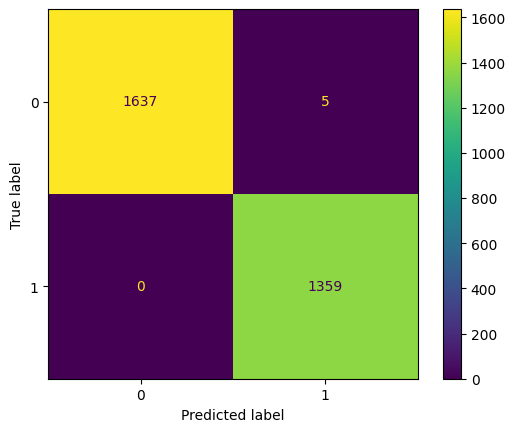

In [14]:
# SVM Model
sv = SVC(C=1000)
sv.fit(X_train, y_train)
scores = cross_val_score(sv, X_test, y_test, cv=10)
print("SVM Score:", np.mean(scores))
ConfusionMatrixDisplay.from_estimator(sv, X_test, y_test)
plt.show()

Decision Tree Score: 0.9940000000000001


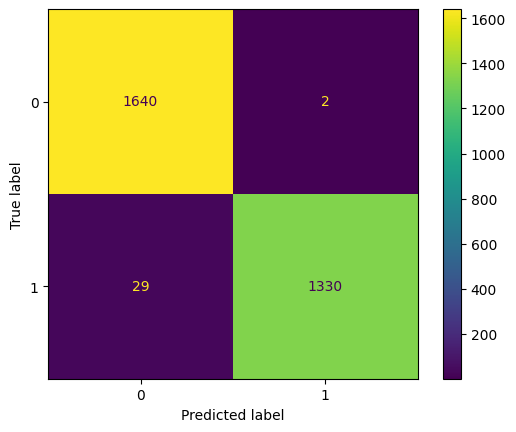

In [15]:
# Decision Tree Model
dtc = DecisionTreeClassifier(criterion='gini', ccp_alpha=0.0012)
dtc.fit(X_train, y_train)
scores = cross_val_score(dtc, X_test, y_test, cv=10)
print("Decision Tree Score:", np.mean(scores))
ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)
plt.show()

KNN Score: 0.9956666666666667


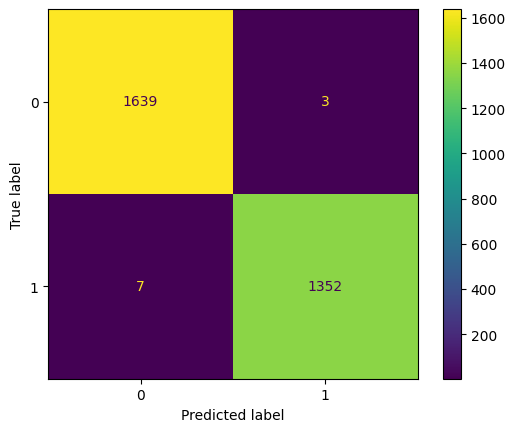

In [16]:
# KNN Model
knn = KNeighborsClassifier(leaf_size=1, n_neighbors=5, p=1)
knn.fit(X_train, y_train)
scores = cross_val_score(knn, X_test, y_test, cv=10)
print("KNN Score:", np.mean(scores))
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.show()

Random Forest Score: 0.9880000000000001


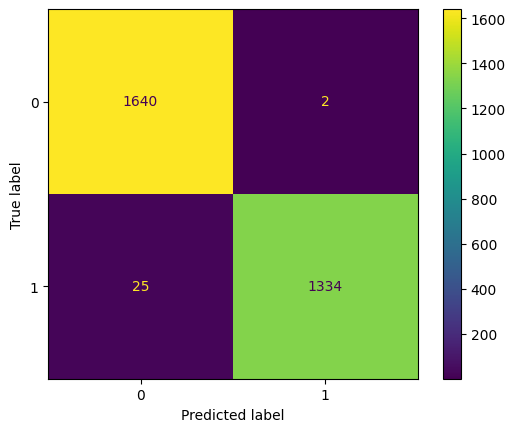

In [17]:
# Random Forest Model
rfclf = RandomForestClassifier(max_depth=6, min_samples_leaf=10, min_samples_split=15, n_estimators=10)
rfclf.fit(X_train, y_train)
scores = cross_val_score(rfclf, X_test, y_test, cv=10)
print("Random Forest Score:", np.mean(scores))
ConfusionMatrixDisplay.from_estimator(rfclf, X_test, y_test)
plt.show()